In [1]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

import os
from configs.base_config import TrainingConfig
from pipelines.pipeline_tensor import DDPMPipeline_Tensor
from pipelines.State import Observer
import torch
from Diffusion_Model.pipelines.new_constraint import *
from DataLoader import get_dataloader, get_infos
from TransformFields import TransformationPipeline
from torch.autograd.functional import vjp
from functools import partial
import pandas as pd

def plot(x, *args, **kwargs):
    xd = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    return plt.plot(xd,  *args, **kwargs)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [368]:
model_path = f'{os.environ["OCEANDATA"]}/models/dino-fusion/tav0h83b/'
pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to('mps')

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [369]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
observer = Observer('data', config)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [370]:
tr = TransformationPipeline(get_infos(config.data_file), config.fields, config.normalisation, device='mps')
train_dataloader = get_dataloader(config.data_file, tr, batch_size=1)
idt = iter(train_dataloader)
data = next(idt)

fixed_start = torch.randn_like(data)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


## Constraint with latent-projection

We need : 
$\newcommand{\R}{\mathbb R}$

$g : \R^I \to \R^K$ : observation operator 

$\mathcal P : \R^K \to \mathcal C^K$ : projection operator

In [388]:
import napari

In [390]:
v = napari.Viewer()

In [392]:
v.add_image(data.cpu().numpy())

<Image layer 'Image' at 0x311cb8aa0>

In [136]:
g = partial(observer.density, result='strided')
p = IsotonicDensity()
p_data = BorderZero(observer)

def L_r(x, z, lbd, rho) : 
    """
        x (n (2*k +1)  i j) -> g(x) (n k i j)
        z (n k) or (n k i j)
        lbd (k) or (k)
        rho (1)
    """
    gx = g(x)
    diff = (g(x) - z).nan_to_num(0.0)
    E_d_sq = (diff**2).sum(axis=1).mean() # (1)
    E_d = einops.reduce(diff, 'n k ... -> k', 'mean')
    return rho*E_d_sq + lbd@E_d, {'E_d_sq' : E_d_sq.detach(), 'E_d' : E_d.detach()}

In [158]:
#dt = 1
#dt = 0.0001
eta, eta_rho =  7e-3, 3e-3

x = torch.randn_like(data) # (B, 2K + 1, I, J)
x.requires_grad_(True)
rho = torch.tensor(0.0, requires_grad=True, device=x.device) # (1)
lbd = torch.zeros((g(x).shape[1]), requires_grad=True, device=x.device) # (K)

metrics = []
pbar = pipeline.progress_bar(pipeline.scheduler.timesteps)
for t in pbar: #pipeline.scheduler.timesteps
    z = p(g(x) + lbd[None, :, None, None] / (2*rho)) # (B, K) or (B, K, I, J)
    l, m = L_r(x, z, lbd, rho)
    l.backward()
    
    with torch.no_grad():
        model_output = pipeline.unet(x, t).sample
        x = pipeline.scheduler.step(model_output - x.grad, t, x).prev_sample # x + dt* ∇log p(x)
        x = p_data(x)
        lbd += eta*lbd.grad
        rho += eta_rho*rho.grad
        rho.clamp_(min=0.01)
    x.grad, lbd.grad = None, None
    x.requires_grad_(True)
    metric = {'t' : int(t), 'rho', rho, 'mean(lbd)' : lbd.mean().item(), 'E[||g(x) - z||^2]' : m['E_d_sq'].item()}
    metrics.append(metric)
    pbar.set_postfix(metric)
gen = x.detach().cpu()
metrics = pd.DataFrame(metrics)

  0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: >

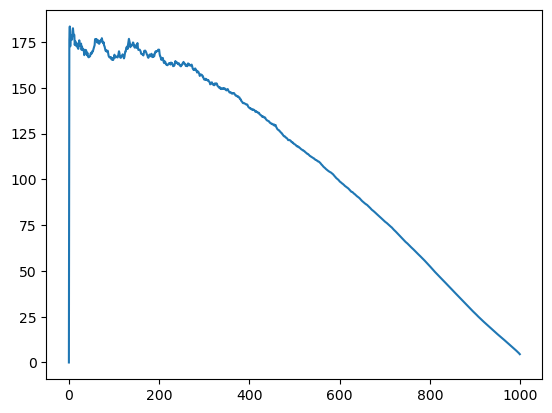

In [162]:
metrics['E[||g(x) - z||^2]'].plot()

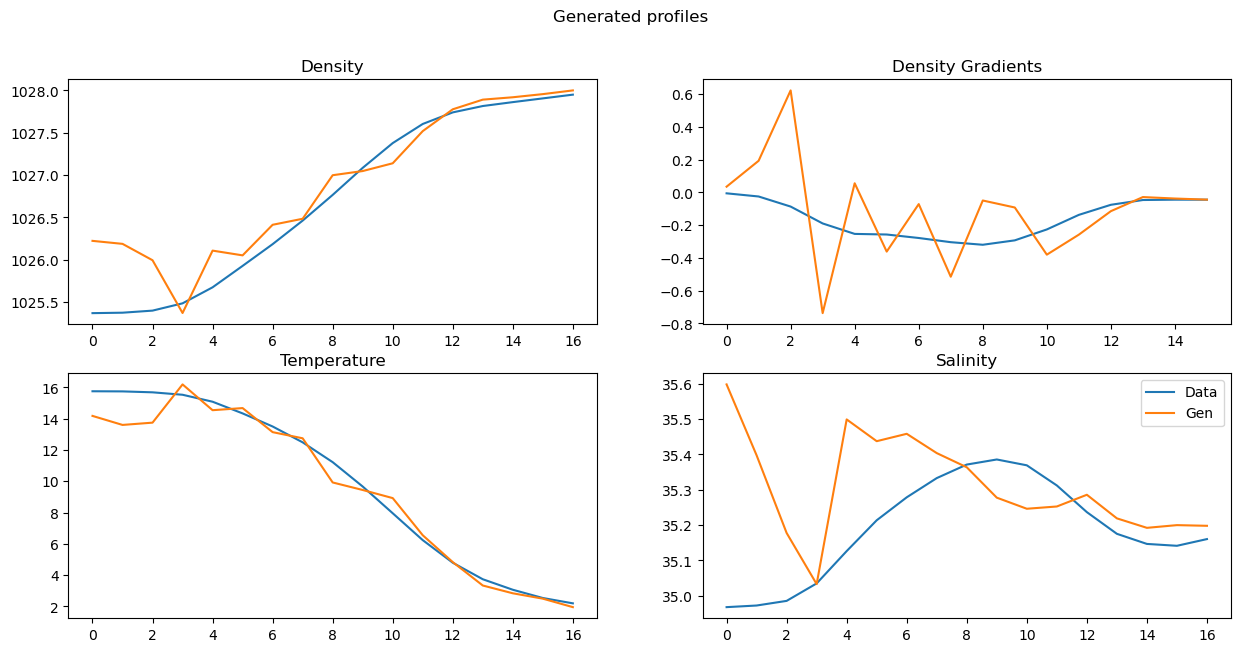

In [152]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : partial(observer.density, result='strided'),
        'Density Gradients' : partial(observer.density_gradient, result='strided'),
        'Temperature' : (lambda x : observer.unnormalized(x, result='strided')['toce']),
        'Salinity' : (lambda x : observer.unnormalized(x, result='strided')['soce'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

(<Figure size 1500x400 with 4 Axes>,
 array([<Axes: title={'center': 'data layer=-1'}>,
        <Axes: title={'center': 'Clusters'}>,
        <Axes: title={'center': 'Cluster Map'}>], dtype=object))

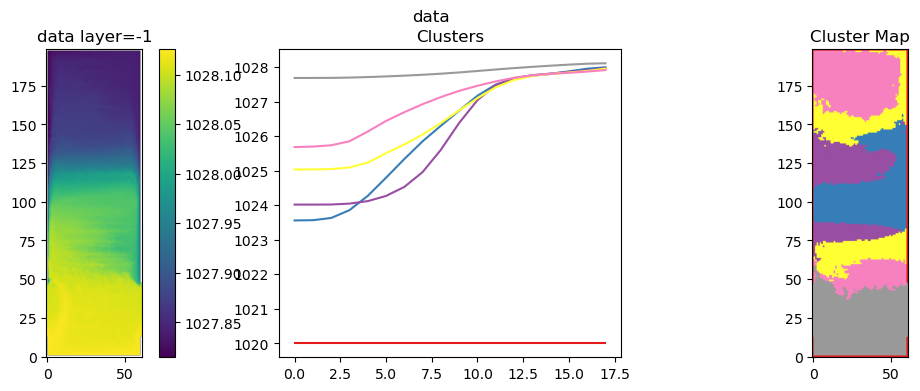

In [123]:
plot_cluster_data(g(data)[0].cpu(), name='data', show_layer=0)

(<Figure size 1500x400 with 4 Axes>,
 array([<Axes: title={'center': 'data layer=0'}>,
        <Axes: title={'center': 'Clusters'}>,
        <Axes: title={'center': 'Cluster Map'}>], dtype=object))

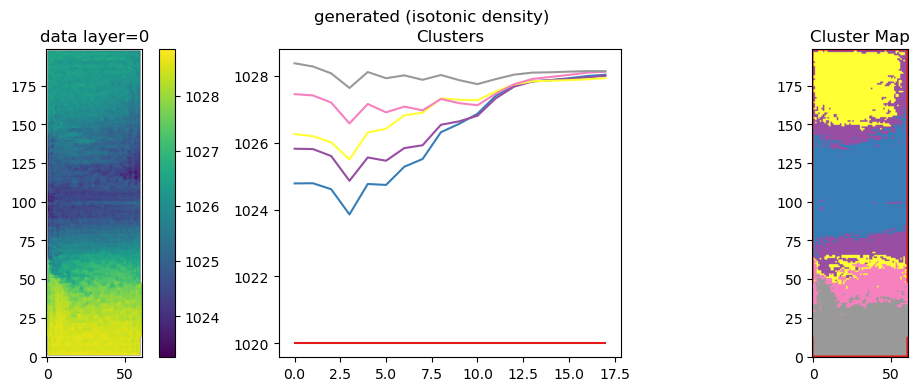

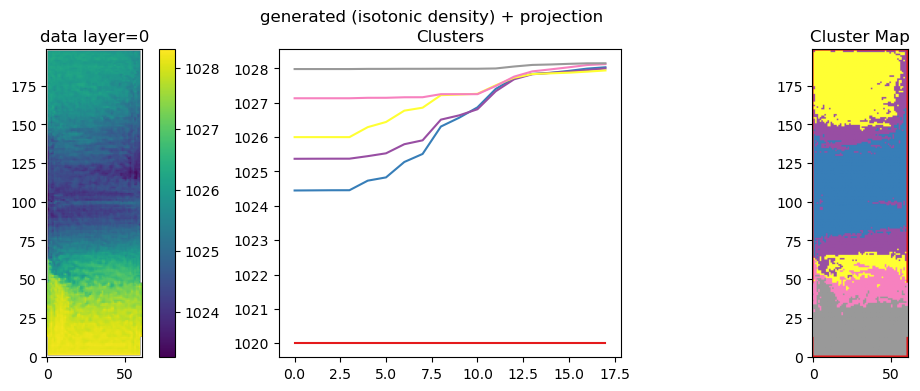

In [156]:
plot_cluster_data(g(gen)[0].detach().cpu(), name='generated (isotonic density)', show_layer=0)

(<Figure size 1500x400 with 4 Axes>,
 array([<Axes: title={'center': 'data layer=0'}>,
        <Axes: title={'center': 'Clusters'}>,
        <Axes: title={'center': 'Cluster Map'}>], dtype=object))

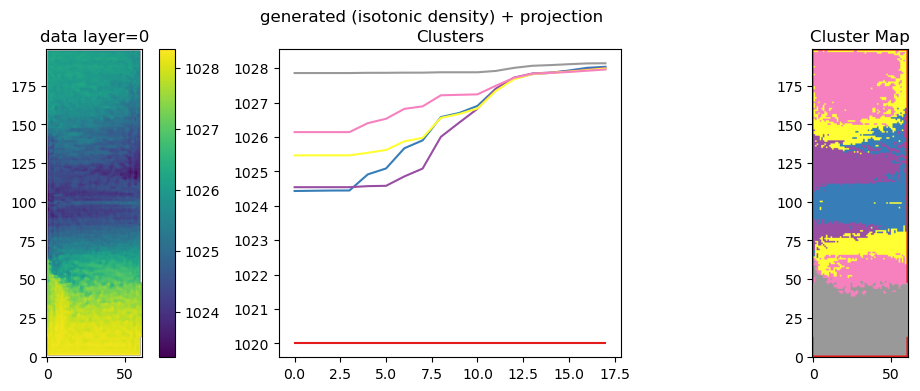

In [157]:
plot_cluster_data(p(g(gen))[0].detach().cpu(), name='generated (isotonic density) + projection', show_layer=0)

In [147]:
diff = (p(g(gen)) - g(gen))
(diff**2).sum(axis=1).nanmean() # (1)

tensor(0.7001, device='mps:0')

In [95]:
v.add_image(g(data).cpu(), name='density_data')

<Image layer 'density_data' at 0x309bf4290>

In [96]:
v.add_image(g(x).detach().cpu(), name='density_gen')

<Image layer 'density_gen' at 0x32a8a5160>

In [99]:
v.add_image((((g(data)[0] - g(x)[0]))).detach().cpu(), name='error')

<Image layer 'error [2]' at 0x3339c7d10>

In [84]:
g(data).shape

torch.Size([1, 18, 199, 62])

In [337]:
from tensordict.tensordict import TensorDict

def __uncall__(self, concatenated_fields, result='file') : 
        # Unpad
        f = self.padder.__uncall__(concatenated_fields.to(self.device))

        if result == 'masked' : return f

        # Restore Edges
        f = self.masker.__uncall__(f)

        if result == 'normalized' : return f

        ## Normalise volume
        #f = self.normaliser.__uncall__(f)

        if result == 'concatenated' : return f

        # Unconcat 
        f = self.concatener.__uncall__(f)

        if result == 'strided' : return f

        # Unstride
        f = TensorDict({k : s.__uncall__(f[k]) for k, s in self.striders.items()}, batch_size=[])

        f = f.apply(self.dimcheck.__uncall__)
        return f

In [343]:
grad_dict =  observer.normalizer.concatener.__uncall__(x.grad[0])

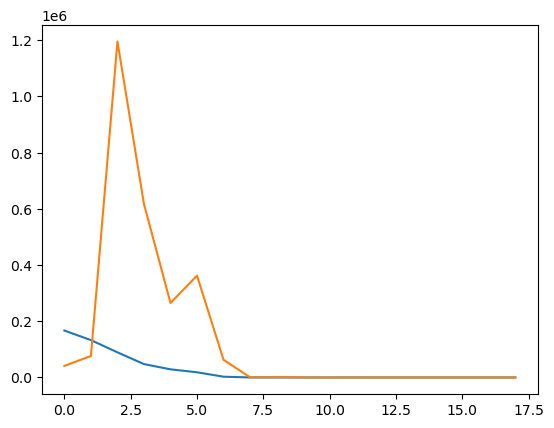

In [355]:
plot((grad_dict['soce']**2).sum(axis=(1,2)))
plot((grad_dict['toce']**2).sum(axis=(1,2)))

In [358]:
grad_dict['ssh'].max()

tensor(0., device='mps:0')